# Técnicas avanzadas de diseño de software

## Sh: Diseño e implementación

### Agustín Borda, Tomás Eslava, Luigi Finetti

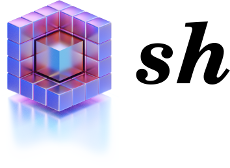



```bash
#!/bin/bash

cases=($(perl -n -e 'if($_ =~ /\[Config (.*)\]/){print "$1 "}' < omnetpp.ini))
mkdir -p csv
for c in "${cases[@]}"
do
	./lab4 -u Cmdenv -c $c
	printf "Exportando %-35s: " $c
	~/omnetpp-6.0/bin/opp_scavetool export\
		-f "runattr:configname=~\"$c\""\
		-F CSV-R -o csv/data-$c.csv results/*.vec results/*.sca
done
```

```python
import os, subprocess, re, glob

def main():
    with open("omnetpp.ini", "r") as f:
        content = f.read()
    cases = re.findall(r"\[Config (.*?)\]", content)
    os.makedirs("csv", exist_ok=True)
    for c in cases:
        subprocess.run(["./lab4", "-u", "Cmdenv", "-c", c], check=True)
        print(f"Exportando {c:<35}: ", end="")
        vec_files = glob.glob("results/*.vec")
        sca_files = glob.glob("results/*.sca")
        all_files = vec_files + sca_files
        try:
            subprocess.run(
                [
                    os.path.expanduser("~/omnetpp-6.0/bin/opp_scavetool"),
                    "export",
                    "-f", f'runattr:configname=~"{c}"',
                    "-F", "CSV-R",
                    "-o", f"csv/data-{c}.csv",
                    *all_files,
                ], check=True
            )
            print("OK")
        except subprocess.CalledProcessError as e:
            print("Error:", e.stderr)

if __name__ == "__main__":
    main()
```

```python
import os, re, sh

lab4 = sh.Command('./lab4').bake(u = "Cmdenv")
scavetool = sh.Command('~/omnetpp-6.0/bin/opp_scavetool').bake('export', F='CSV-R')

def main():
    with open("omnetpp.ini", "r") as f:
        content = f.read()
    cases = re.findall(r"\[Config (.*?)\]", content)
    os.makedirs("csv", exist_ok=True)
    for c in cases:
        lab4(c = c)
        print(f"Exportando {c:<35}: ", end="")
        scavetool.bake(f=f'runattr:configname=~"{c}"', o=f"csv/data-{c}.csv")(sh.glob("results/*.vec"), sh.glob("results/*.sca"))

if __name__ == "__main__":
    main()
```

# Módulo
1. Cómo funciona `import sh`
2. Un ejemplo reutilizable
3. `run_repl()`
4. Tangentes


## Cómo funciona `import sh`

- ¿Qué se ejecuta cuando hacemos `import x`?  
Se ejecuta todo el código del módulo, y lo que quedó en `globals()` del módulo se asigna a `x`
- ¿Y si hago `from x import y`?  
Lo mismo, se ejecuta todo y `globals()['y']` se asigna a `y`

## Cómo funciona `import sh`

- ¿Y con `from x import *`?
Se ejecuta el módulo y se busca `__all__`.  
Si lo encuentra, lo itera y va importando esos elementos.  
Sino, importa todo lo que encontró _(excepto cosas que empiecen con `_`)_
- ¿Y cómo funciona `from sh import ls` si no definí `ls`?  
✨ Magia ✨

### Nivel 1 de magia:
```python
if __name__ == "__main__":
    # we're being run as a stand-alone script
    env = Environment(globals())
    run_repl(env)
else:
    # we're being imported from somewhere
    sys.modules[__name__] = SelfWrapper(sys.modules[__name__])
```
Vemos un clásico de Python: `if __name__ == "__main__"`

`sh` detecta si lo ejecutamos (`python -m sh`) o lo importamos. Por ahora nos interesa el segundo caso. ¿Qué será `SelfWrapper`?


### Nivel 2 de magia:
```python
# versión abreviada
# `SelfWrapper` extiende a `ModuleType`, el tipo de los módulos.
class SelfWrapper(ModuleType):
    def __init__(self, self_module):
        # Crea un módulo limpio
        super().__init__(
            name=getattr(self_module, "__name__", None),
            doc=getattr(self_module, "__doc__", None),
        )
        # Copia ciertos atributos
        for attr in ["__builtins__", "__file__", "__package__"]:
            setattr(self, attr, getattr(self_module, attr, None))

        # ¿Qué será Environment?
        self.__env = Environment(globals())

    # Cuando le pidamos un atributo y no lo encuentre, se lo pide a Environment
    def __getattr__(self, name):
        return self.__env[name]
```

### Nivel 3 de magia:
```python
# versión abreviada
# Environment extiende un diccionario. Más adelante vemos por qué
class Environment(dict):
    # Clases y funciones que exponemos al usuario de la biblioteca
    allowlist = { "Command", "RunningCommand" } # ...
    # por globs va a recibir globals(), que es todo lo definido en el módulo
    def __init__(self, globs):
        super(dict, self).__init__()
        self.globs = globs
    # Haciendo sh.ls -> SelfWrapper().ls -> Environment()['ls']
    def __getitem__(self, k):
        if k in self.allowlist: return self.globs[k]

        if k == "__all__":
            warnings.warn( "Cannot import * from sh.")
            return []

        exc = get_exc_from_name(k)
        if exc: return exc

        cmd = resolve_command(k, self.globs[Command.__name__], self.baked_args)
        if cmd: return cmd

        try: return os.environ[k]
        except KeyError: pass

        raise CommandNotFound(k)
```

## Un ejemplo reutilizable
```python
from types import ModuleType
import sys
_db = {'users': [], 'products': []}

class SelfWrapper(ModuleType):
    def __init__(self, self_module):
        super().__init__(name=getattr(self_module, "__name__", None), doc=getattr(self_module, "__doc__", None))
        for attr in self_module.__dict__:
            setattr(self, attr, getattr(self_module, attr))

    def __getattr__(self, attr):
        if attr == "__all__": return []
        # table_name = get_users -> users
        if attr.startswith('get_'):
            def f():
                return _db[attr[4:]]
            f.__qualname__ = attr
            return f
        raise AttributeError(f"module '{self.__name__}' has no attribute '{attr}'")

sys.modules[__name__] = SelfWrapper(sys.modules[__name__])
```
Nota: un simple `def __getattr__()` parece funcionar, pero no podríamos modificar la clase original. Y por ejemplo, `def __getitem__()` no funciona sin este Wrapper.

## Volviendo: ¿Y `run_repl`?
Recordemos el nivel 1:
```python
if __name__ == "__main__":  # pragma: no cover
    # we're being run as a stand-alone script
    env = Environment(globals())
    run_repl(env)
else:
    # we're being imported from somewhere
    sys.modules[__name__] = SelfWrapper(sys.modules[__name__])
```


## Volviendo: ¿Y `run_repl`?
```python
def run_repl(env):  # pragma: no cover
    print(f"\n>> sh v{__version__}\n>> https://github.com/amoffat/sh\n")

    while True:
        try:
            line = input("sh> ")
        except (ValueError, EOFError):
            break

        try:
            exec(compile(line, "<dummy>", "single"), env, env)
        except SystemExit:
            break
        except:  # noqa: E722
            print(traceback.format_exc())

    # cleans up our last line
    print("")
```
Nos permite hacer `$ python -m sh`.

## Volviendo: ¿Y `run_repl`?
Sin embargo, si lo intentamos usar va a ser... decepcionante.
```python
$ python -m sh
>> sh v2.2.1
>> https://github.com/amoffat/sh

sh> a = '..'
sh> ls(a)
Traceback (most recent call last):
  File "/home/luigi/tads/venv/lib/python3.12/site-packages/sh.py", line 3617, in run_repl
    exec(compile(line, "<dummy>", "single"), env, env)
  File "<dummy>", line 1, in <module>
  File "/home/luigi/tads/venv/lib/python3.12/site-packages/sh.py", line 3441, in __getitem__
    raise CommandNotFound(k)
CommandNotFound: a

sh> dir = 'students' 
sh> ls(dir)
'/usr/bin/dir\n'

```

## Metaprogramación con `exec`
### Documentación relevante
```
>>> help(exec)
exec(source, globals=None, locals=None, /, *, closure=None)
    Execute the given source in the context of globals and locals.

    The source may be a string representing one or more Python statements
    or a code object as returned by compile().
    The globals must be a dictionary and locals can be any mapping,
    defaulting to the current globals and locals.
    If only globals is given, locals defaults to it.
    The closure must be a tuple of cellvars, and can only be used
    when source is a code object requiring exactly that many cellvars.
```

## Metaprogramación con `exec`
El problema radica en `exec(compile(line, "<dummy>", "single"), env, env)`.

Pasamos nuestro `Environment` como `globals` y como `locals`.

Luego, al setear `a` estaremos haciendo `locals.__setitem__(a, '..')`.

Finalmente para leer `a` hacemos `locals.__getitem__(a)`, que es el mecanismo personalizado, y no encuentra `a`.

## Metaprogramación con `exec`
En resumen, `Environment` es un muy mal `dict` (o, mejor dicho, dice ser un `dict` pero no cumple las propiedades que esperaríamos, como que después de insertar un elemento lo podamos leer)

¿Y si hacemos `exec(compile(line, "<dummy>", "single"), env, locals_dict)`?
```
sh> a='..' 
sh> a
'..'
sh> ls(a)
Traceback (most recent call last):
  File "/home/luigi/sh/sh.py", line 3620, in run_repl
    exec(compile(line, "<dummy>", "single"), env, mydict)
  File "<dummy>", line 1, in <module>
NameError: name 'ls' is not defined

```


## `exec` es engañoso

In [20]:
def f1(): print('f1')
def f2(): print('F2')
exec('f()', {'f':f1}, {'f':f2})
exec('f()', {'f':f1}, {})
try: exec('f()', {}, {})
except NameError as e: print(f'{e=} # No encontró f(), OK')

F2
f1
e=NameError("name 'f' is not defined") # No encontró f(), OK


In [22]:
class mydict(dict):
  def __getitem__(self, key): 
    print('accessing', key)
    if key == 'f': return f1
    return super().__getitem__(key)
  
exec('f()', mydict(), {'f':f2})
# exec('f()', mydict(), {})
try: exec('f()', mydict(), {})
except NameError as e: print(f'{e=} # ¿Por qué no encontró f()?')

F2
e=NameError("name 'f' is not defined") # ¿Por qué no encontró f()?


## `exec` es engañoso
Hilando fino, en la documentación completa de Python [se explicita que `globals` debe ser un diccionario y no una subclase del mismo](https://docs.python.org/3.14/library/functions.html#exec:~:text=If%20only%20globals%20is%20provided%2C%20it%20must%20be%20a%20dictionary%20(and%20not%20a%20subclass%20of%20dictionary))

CPython, sin embargo, no chequea esto.
```c
/* Python/bltinmodule.c, L1070 */
static PyObject *
builtin_exec_impl(PyObject *module, PyObject *source, PyObject *globals,
                  PyObject *locals, PyObject *closure)
{ /* ... */
    if (!PyDict_Check(globals)) {
        PyErr_Format(PyExc_TypeError, "exec() globals must be a dict, not %.100s",
                     Py_TYPE(globals)->tp_name);
        goto error;
    }
/* ... */
}
```
Se solucionaría cambiando `PyDict_Check` por `PyDict_CheckExact`


## `exec` es engañoso
Si lo cambiamos se rompen un par de tests (`test_builtin, test_descrtut, test_dynamic, test_getpath, test_type_aliases`, o 5 de 459).

Acá incluso encontramos que `test_exec_globals_error_on_get` de `test_builtin` está mal (no testea lo que dice testear):
```python
    def test_exec_globals_error_on_get(self):
        # custom `globals` or `builtins` can raise errors on item access
        class setonlyerror(Exception):
            pass
        class setonlydict(dict):
            def __getitem__(self, key):
                raise setonlyerror
        code = compile("globalname", "test", "exec")
        self.assertRaises(setonlyerror,
                          exec, code, setonlydict({'globalname': 1}))
```



## Cómo Python carga las variables
```c
/* Python/ceval.c, L3340 */
PyObject *
_PyEval_LoadName(PyThreadState *tstate, _PyInterpreterFrame *frame, PyObject *name)
{
    PyObject *value;
    if (frame->f_locals == NULL) {
        _PyErr_SetString(tstate, PyExc_SystemError,
                            "no locals found");
        return NULL;
    }
    if (PyMapping_GetOptionalItem(frame->f_locals, name, &value) < 0) {
        return NULL;
    }
    if (value != NULL) {
        return value;
    }
    if (PyDict_GetItemRef(frame->f_globals, name, &value) < 0) {
        return NULL;
    }
    if (value != NULL) {
        return value;
    }
    if (PyMapping_GetOptionalItem(frame->f_builtins, name, &value) < 0) {
        return NULL;
    }
    if (value == NULL) {
        _PyEval_FormatExcCheckArg(
                    tstate, PyExc_NameError,
                    NAME_ERROR_MSG, name);
    }
    return value;
}
```



Nota:
Todo esto está documentado [en un artículo de Guido Van Rossum de 2002](https://www.python.org/download/releases/2.2.3/descrintro/#:~:text=However%2C%20our%20__getitem__()%20method%20is%20not%20used%20for%20variable%20access%20by%20the%20interpreter%3A). Ahí decía:

> El intérprete usa una función interna para acceder al diccionario, que se saltea nuestro `__getitem__()` personalizado. Admito que esto puede ser un problema; queda por verse si puedo arreglar esto sin sacrificar rendimiento en el caso usual.

Han pasado 23 años.

# sh: Manejo de Excepciones

## Metaprogramación - type

![objeto-clase-metaclase](exc_media/instance-of.png)

## Clases Protagonistas


### ErrorReturnCodeMeta

In [1]:
class ErrorReturnCodeMeta(type): # El creador
	"""
	a metaclass which provides the ability for an ErrorReturnCode (or
	derived) instance, imported from one sh module, to be considered the
	subclass of ErrorReturnCode from another module.
	"""
	def __subclasscheck__(self, o):
		other_bases = {b.__name__ for b in o.__bases__}
		return self.__name__ in other_bases or o.__name__ == self.__name__

- - -
### ErrorReturnCode

In [2]:
class ErrorReturnCode(Exception): # El blueprint
	__metaclass__ = ErrorReturnCodeMeta

    def __reduce__(self):
        return self.__class__, (self.full_cmd, self.stdout, self.stderr, self.truncate)

    def __init__(self, full_cmd, stdout, stderr, truncate=True):
        self.exit_code = self.exit_code  # makes pylint happy
        self.full_cmd = full_cmd
        self.stdout = stdout
        self.stderr = stderr
        self.truncate = truncate

    	# Resto de __init__()...

## Dado un código de error, ¿qué excepción levantamos?

*ErrorReturnCode* y *ErrorReturnCodeMeta* no se instancian **nunca**.

![jerarquía](exc_media/Sh_module.png)

## ¿Qué recorrido hace la información?

In [ ]:
# Dentro del código de OProc, correspondiente al proceso padre
                def fn(exit_code):
                    with process_assign_lock:
                        return self.command.handle_command_exit_code(exit_code)

                handle_exit_code = fn

# O dentro del código para wait() de RunningCommand
    if self.process.timed_out:
                # if we timed out, our exit code represents a signal, which is
                # negative, so let's make it positive to store in our
                # TimeoutException
                raise TimeoutException(-exit_code, self.ran)

            else:
                self.handle_command_exit_code(exit_code)

### ... donde este método se define de la siguiente manera:

In [ ]:
# RunningCommand
def handle_command_exit_code(self, code):
"""
Vemos si se produjo una excepción o recibimos un código de error inesperado. 
De ser así, creamos y levantamos la excepción correspondiente
"""
	ca = self.call_args # call_args se define en Command
	exc_class = get_exc_exit_code_would_raise(code, ca["ok_code"], ca["piped"])
	if exc_class:
		exc = exc_class(
			self.ran, 
			self.process.stdout, 
			self.process.stderr,
			ca["truncate_exc"]
			)
		raise exc

### Tirando del hilo...

In [ ]:
def get_exc_exit_code_would_raise(exit_code, ok_codes, sigpipe_ok):
	exc = None
	success = exit_code in ok_codes
	bad_sig = -exit_code in SIGNALS_THAT_SHOULD_THROW_EXCEPTION
	
	# if this is a piped command, SIGPIPE must be ignored by us and not raise an
	# exception, since it's perfectly normal for the consumer of a process's
	# pipe to terminate early
	
	if sigpipe_ok and -exit_code == signal.SIGPIPE:
		bad_sig = False
		success = True
	
	if not success or bad_sig:
		exc = get_rc_exc(exit_code)
	return exc

### Alternativamente, dentro del dunder __call__() de Command:

In [ ]:
# if we're running in foreground mode, we need to completely bypass
# launching a RunningCommand and OProc and just do a spawn
        if call_args["fg"]:
            cwd = call_args["cwd"] or os.getcwd()
            with pushd(cwd):
                if call_args["env"] is None:
                    exit_code = os.spawnv(os.P_WAIT, cmd[0], cmd)
                else:
                    exit_code = os.spawnve(os.P_WAIT, cmd[0], cmd, call_args["env"])

            exc_class = get_exc_exit_code_would_raise(
                exit_code, call_args["ok_code"], call_args["piped"]
            )
            if exc_class:
                ran = " ".join(cmd)
                exc = exc_class(ran, b"", b"", call_args["truncate_exc"])
                raise exc
            return None

In [ ]:
def get_rc_exc(rc):
"""
takes a exit code or negative signal number and produces an exception
that corresponds to that return code. positive return codes yield
ErrorReturnCode exception, negative return codes yield SignalException
we also cache the generated exception so that only one signal of that type
exists, preserving identity
"""
	try:
		return rc_exc_cache[rc]
	except KeyError:
		pass
	
	if rc >= 0:
		name = f"ErrorReturnCode_{rc}"
		base = ErrorReturnCode
	
	else:
		name = f"SignalException_{SIGNAL_MAPPING[abs(rc)]}"
		base = SignalException
	
	exc = ErrorReturnCodeMeta(name, (base,), {"exit_code": rc}) # << Creación de la excepción >>
	rc_exc_cache[rc] = exc
	return exc

### ... donde

In [ ]:
rc_exc_cache: Dict[str, Type[ErrorReturnCode]] = {}

# Contrib Commands


## Qué son?
    
    Son wrappers fáciles de usar de comandos de shell complejos.

In [9]:
import sh
from sh.contrib import sudo
from sh import Command
ls = Command("ls")
my_password = "Agustin18898\n"

## Usando sudo con contrib vs sin contrib

In [6]:
with sudo:
    print(ls("/"))

[sudo] password for aborda:  ········


.VolumeIcon.icns	System			home
.file			Users			opt
.nofollow		Volumes			private
.resolve		bin			sbin
.vol			cores			tmp
Applications		dev			usr
Library			etc			var



In [10]:
my_sudo = sh.sudo.bake("-S", _in=my_password)
print(my_sudo.ls("/"))

.VolumeIcon.icns	System			home
.file			Users			opt
.nofollow		Volumes			private
.resolve		bin			sbin
.vol			cores			tmp
Applications		dev			usr
Library			etc			var



## Pero y si no quiero poner mi contraseña cada vez?

In [12]:
with sudo(password=my_password, _with=True):
    print(ls("/"))

.VolumeIcon.icns	System			home
.file			Users			opt
.nofollow		Volumes			private
.resolve		bin			sbin
.vol			cores			tmp
Applications		dev			usr
Library			etc			var



## Me puedo definir mis propios wrappers?
    Se pueden agregar comandos contrib utilizando el decorator "@contrib", por ejemplo:

In [33]:
from sh import contrib
@contrib("echo")
def echo(original):
    return original.bake("-n")


In [34]:
from sh.contrib import echo
echo("Hello!")

'Hello!'

## El patrón decorator

![title](resources/decorator.png)

## El patrón decorator

Mientras tengamos en mente este patrón de diseño, es fácil agregar contrib commands. Sin embargo este módulo tiene algunas limitaciones:

- Solamente es posible crear contrib commands de comandos ya existentes.
- Por cómo funciona el módulo, solo se pueden decorar los comandos una sola vez.

## Cómo funciona este módulo?
    Código del módulo Contrib:

In [ ]:
#Nota: no me ejecutes! Soy código robado!
class Contrib(ModuleType):  # pragma: no cover
    @classmethod
    def __call__(cls, name):
        def wrapper1(fn):
            @property
            def cmd_getter(self):
                cmd = resolve_command(name, Command)

                if not cmd:
                    raise CommandNotFound(name)

                new_cmd = fn(cmd)
                return new_cmd

            setattr(cls, name, cmd_getter)
            return fn

        return wrapper1


mod_name = __name__ + ".contrib"
contrib = Contrib(mod_name)
sys.modules[mod_name] = contrib


## Muy bonito, pero que hace?

Vamos por partes

In [ ]:
            def cmd_getter(self):
                cmd = resolve_command(name, Command)

                if not cmd:
                    raise CommandNotFound(name)

                new_cmd = fn(cmd)
                return new_cmd

Esto nos busca el comando original en nuestro sistema y lo decora con la función que le pasamos, ejecutándose primero la nueva función y después el comando original.

## Muy bonito, pero que hace?

In [ ]:
        def wrapper1(fn):
            @property
            ...

            setattr(cls, name, cmd_getter)
            return fn

Luego esta parte crea un nuevo atributo con el nombre del comando en el objeto contrib, cuyo valor es el Command decorado!

In [37]:
getattr(contrib,"echo")

<Command '/bin/echo -n'>

## Muy bonito, pero que hace?

In [ ]:
class Contrib(ModuleType):  # pragma: no cover
    @classmethod
    def __call__(cls, name):
        ...

        return wrapper1

Esto nos convierte la clase en ejecutable, lo que nos permite utilizar la sintaxis de operadores en python  

In [ ]:
mod_name = __name__ + ".contrib"
contrib = Contrib(mod_name)
sys.modules[mod_name] = contrib

Finalmente, creamos un objeto de la clase Contrib y lo agregamos a los módulos del sistema.